In [1]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
from matplotlib.cm import get_cmap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
from matplotlib.patches import Rectangle
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import tkinter as tk
from tkinter import ttk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import colormaps
from matplotlib.patches import Rectangle
import matplotlib.cm as cm
import matplotlib.colors as colors
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.cm as cm
import warnings
warnings.filterwarnings("ignore", message="This figure includes Axes that are not compatible with tight_layout")
%matplotlib inline

#### loading geopotential at 0LST

In [2]:
path = '/home/annierosen16/data/era5sgp/era5_sl_850_geopotential_full_us'

z850_files = sorted(glob.glob(f"{path}/*.nc"))

z850 = xr.open_mfdataset(z850_files, combine="by_coords")

z850['valid_time'] = z850['valid_time'] - pd.Timedelta(hours=6)

_0lst_z850 = z850.sel(valid_time=z850.valid_time.dt.hour == 0)

_0lst_z850 = _0lst_z850.sel(pressure_level=850)

_0lst_z850 = _0lst_z850.rename({"valid_time": "time"})

In [3]:
# reading in ERA5 u, v, w and q

base_path = '/data/rong4/Data/ERA5/3hourly/quvw_US'

years = [str(year) for year in range(2001, 2019)]

def get_files(folder, component):

    files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))

    filtered_files = [f for f in files if any(year in f for year in years)]
    
    return filtered_files

# Get the files for each component

u_files = get_files('u_component_of_wind', 'u_component_of_wind')

v_files = get_files('v_component_of_wind', 'v_component_of_wind')

w_files = get_files('vertical_velocity', 'vertical_velocity')

all_files = u_files + v_files + w_files

# open all datasets at once

uvw = xr.open_mfdataset(all_files, combine='by_coords', chunks={'time': 24})

uvw['time'] = uvw['time'] - pd.Timedelta(hours=6)

# edit for pressure level 

winds = uvw.sel(level=uvw.level.isin([850]))

winds = winds.where(
    
    (winds.time.dt.month.isin([5, 6, 7, 8, 9])) &
    
    (winds.time.dt.year.isin(range(2001, 2019))),
    
    drop=True
)

winds = winds.sel(level=850)

_0lst_wind_850 = winds.sel(time=winds.time.dt.hour == 0)

In [4]:
winds = _0lst_wind_850

In [5]:
with open('/home/annierosen16/master.pkl', 'rb') as f:
    
    master = pickle.load(f)

### plotting wind composite

In [9]:
u = _0lst_wind_850['u'].compute()

v = _0lst_wind_850['v'].compute()

In [17]:
# checking for 2011 & 2007

category_1_days = pd.date_range(start="2011-05-01", end="2011-09-30", freq="D").to_list()

category_2_days = pd.date_range(start="2007-05-01", end="2007-09-30", freq="D").to_list()

In [20]:
# composite u and v for category 1 and category 2

u_comp_1 = u.sel(time=category_1_days).mean(dim='time')

v_comp_1 = v.sel(time=category_1_days).mean(dim='time')

u_comp_2 = u.sel(time=category_2_days).mean(dim='time')

v_comp_2 = v.sel(time=category_2_days).mean(dim='time')

wind_speed_1 = np.sqrt(u_comp_1**2 + v_comp_1**2)

wind_speed_2 = np.sqrt(u_comp_2**2 + v_comp_2**2)

wind_speeds = [wind_speed_1, wind_speed_2]

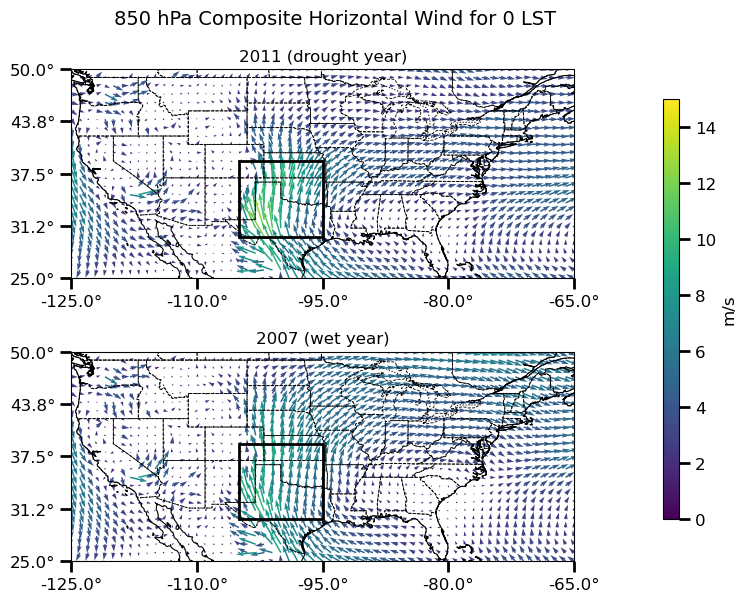

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()})

cmap = cm.viridis

norm = colors.Normalize(vmin=0, vmax=15)

titles = [
    
    "2011 (drought year)",
    
    "2007 (wet year)"
]

composites = [(u_comp_1, v_comp_1), (u_comp_2, v_comp_2)]

wind_magnitudes = wind_speeds[:2]  # Only first two wind speed arrays

# subsample settings and grid prep

lons = _0lst_wind_850['longitude'].values

lats = _0lst_wind_850['latitude'].values

lon_grid, lat_grid = np.meshgrid(lons, lats)

lon_min, lon_max = np.min(lons), np.max(lons)

lat_min, lat_max = np.min(lats), np.max(lats)

quiver_step = 4

# Plot composite wind fields for first two categories

for ax, (u_comp, v_comp), wind_speed, title in zip(axes.flatten(), composites, wind_magnitudes, titles):
    
    ax.set_extent([lon_min, lon_max, lat_min, lat_max-5])

    u_sub = u_comp[::quiver_step, ::quiver_step]
    
    v_sub = v_comp[::quiver_step, ::quiver_step]
    
    wind_speed_sub = wind_speed[::quiver_step, ::quiver_step]
    
    lon_sub = lon_grid[::quiver_step, ::quiver_step]
    
    lat_sub = lat_grid[::quiver_step, ::quiver_step]

    quiv = ax.quiver(
        lon_sub, lat_sub, u_sub, v_sub, wind_speed_sub,
        transform=ccrs.PlateCarree(), scale=200, width=0.003,
        cmap=cmap, norm=norm
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)
    
    ax.add_feature(cfeature.STATES, linestyle="--", linewidth=0.6, edgecolor="black")

    # Highlight SGP box
    
    sgp_lon_min, sgp_lon_max = -105, -95
    
    sgp_lat_min, sgp_lat_max = 30, 39
    
    box = Rectangle((sgp_lon_min, sgp_lat_min), sgp_lon_max - sgp_lon_min, sgp_lat_max - sgp_lat_min,
                    linewidth=2, edgecolor='black', facecolor='none', transform=ccrs.PlateCarree())
    
    ax.add_patch(box)

    ax.set_xticks(np.linspace(lon_min, lon_max, 5), crs=ccrs.PlateCarree())
    
    ax.set_yticks(np.linspace(lat_min, lat_max, 5), crs=ccrs.PlateCarree())
    
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}°"))
    
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}°"))
    
    ax.tick_params(axis='both', which='major', length=8, width=2, labelsize=12)
    
    ax.tick_params(axis='both', which='minor', length=5, width=1.5, labelsize=12)
    
    ax.set_title(title, fontsize=12)


# Add vertical colorbar on the right-hand side

cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])  # [left, bottom, width, height]

cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='vertical')

cbar.ax.tick_params(labelsize=12, length=8, width=2)

cbar.set_label("m/s", fontsize=12)

plt.suptitle("850 hPa Composite Horizontal Wind for 0 LST", fontsize=14, y=1)

plt.subplots_adjust(left=0.08, right=0.89, bottom=0.08, top=0.90, hspace=0.35)

plt.show()